Assignment 5




 * Name: Shlok Nikam
* PRN: 12414145



*   Batch: 2
*   Division: D



*   Branch: CSE(AI)
*   Date: 3/2/2026


Assignment 5: Predict the price of the Uber ride from a given pickup point to the agreed drop-off location. Perform following tasks: 1. Pre-process the dataset. 2. Identify outliers. 3. Check the correlation. 4. Implement linear regression and ridge, Lasso regression models. 5. Evaluate the models and compare their respective scores like R2, RMSE, etc.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

df = pd.read_csv('uber.csv')
print(f"Initial shape: {df.shape}")


Initial shape: (200000, 9)


Data Preprocessing

In [ ]:
# drop unnecessary columns
df = df.drop(['Unnamed: 0', 'key'], axis=1)

# remove missing values
df = df.dropna()

# filter out invalid data points
df = df[df['fare_amount'] > 0]
df = df[df['fare_amount'] < 250]
df = df[(df['pickup_longitude'] >= -75) & (df['pickup_longitude'] <= -72)]
df = df[(df['pickup_latitude'] >= 40) & (df['pickup_latitude'] <= 42)]
df = df[(df['dropoff_longitude'] >= -75) & (df['dropoff_longitude'] <= -72)]
df = df[(df['dropoff_latitude'] >= 40) & (df['dropoff_latitude'] <= 42)]
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] < 7)]

# parse datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year
df['weekday'] = df['pickup_datetime'].dt.weekday

# calculate ride distance
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df['distance'] = haversine_distance(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

df = df[df['distance'] > 0]
df = df[df['distance'] < 50]
df = df[df['fare_amount'] < 100]

print(f"Cleaned shape: {df.shape}")


Cleaned shape: (192961, 13)


Outlier Detection

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for col in ['fare_amount', 'distance', 'passenger_count']:
    n_outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"{col}: {n_outliers} outliers ({n_outliers/len(df)*100:.2f}%)")
    print(f"  Valid range: [{lower:.2f}, {upper:.2f}]")


fare_amount: 16435 outliers (8.52%)
  Valid range: [-3.75, 22.25]
distance: 15988 outliers (8.29%)
  Valid range: [-2.70, 7.92]
passenger_count: 21832 outliers (11.31%)
  Valid range: [-0.50, 3.50]


Box Plots for Univariate Analysis

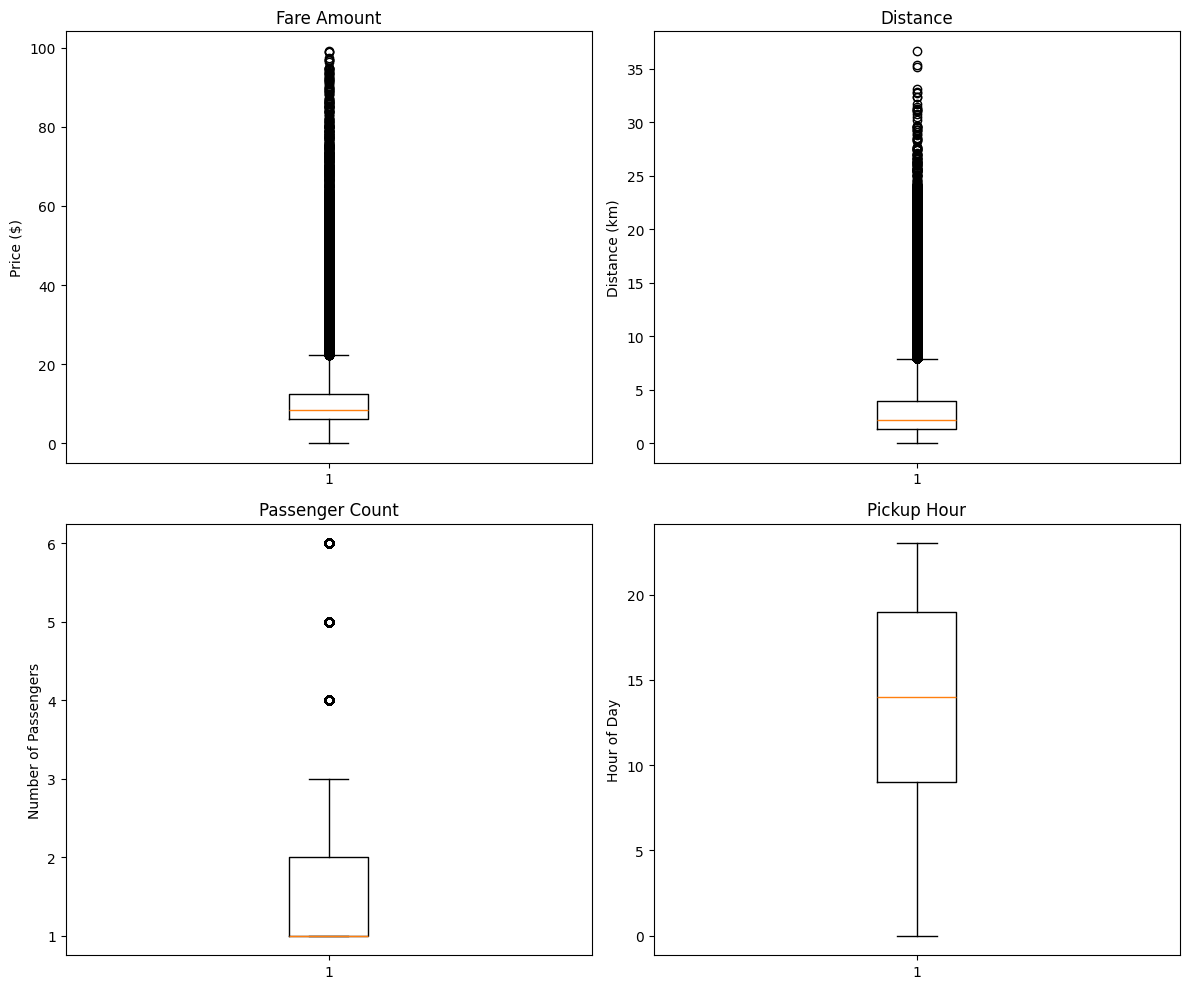

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].boxplot(df['fare_amount'])
axes[0, 0].set_title('Fare Amount')
axes[0, 0].set_ylabel('Price ($)')

axes[0, 1].boxplot(df['distance'])
axes[0, 1].set_title('Distance')
axes[0, 1].set_ylabel('Distance (km)')

axes[1, 0].boxplot(df['passenger_count'])
axes[1, 0].set_title('Passenger Count')
axes[1, 0].set_ylabel('Number of Passengers')

axes[1, 1].boxplot(df['hour'])
axes[1, 1].set_title('Pickup Hour')
axes[1, 1].set_ylabel('Hour of Day')

plt.tight_layout()
plt.show()


Correlation Analysis

In [ ]:

numerical_features = ['fare_amount', 'pickup_longitude', 'pickup_latitude',
                      'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
                      'hour', 'day', 'month', 'year', 'weekday', 'distance']

# pearson correlation (linear relationship)
pearson_corr = df[numerical_features].corr(method='pearson')
print("Pearson Correlation with fare_amount:")
print(pearson_corr['fare_amount'].sort_values(ascending=False))

# spearman correlation (monotonic relationship)
spearman_corr = df[numerical_features].corr(method='spearman')
print("\nSpearman Correlation with fare_amount:")
print(spearman_corr['fare_amount'].sort_values(ascending=False))

# kendall correlation (rank-based)
kendall_corr = df[numerical_features].corr(method='kendall')
print("\nKendall Correlation with fare_amount:")
print(kendall_corr['fare_amount'].sort_values(ascending=False))


Pearson Correlation with fare_amount:
fare_amount          1.000000
distance             0.887859
pickup_longitude     0.426295
dropoff_longitude    0.316089
year                 0.123041
month                0.024740
passenger_count      0.013770
weekday              0.004831
day                  0.000482
hour                -0.020484
dropoff_latitude    -0.184388
pickup_latitude     -0.216053
Name: fare_amount, dtype: float64

Spearman Correlation with fare_amount:
fare_amount          1.000000
distance             0.859053
year                 0.149623
dropoff_longitude    0.109071
pickup_longitude     0.045560
month                0.031845
passenger_count      0.023045
weekday              0.013475
day                  0.003999
hour                -0.006161
pickup_latitude     -0.076504
dropoff_latitude    -0.090806
Name: fare_amount, dtype: float64

Kendall Correlation with fare_amount:
fare_amount          1.000000
distance             0.701634
year                 0.108156
dropo

Train-Test Split


In [ ]:
feature_cols = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
                'dropoff_latitude', 'passenger_count', 'hour', 'day',
                'month', 'year', 'weekday', 'distance']

X = df[feature_cols]
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 154368, Test size: 38593


Model Training

In [ ]:
# linear regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# ridge regression
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

# lasso regression
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

print("All models trained successfully")


All models trained successfully


Model Evaluation & Comparison

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {'Model': model_name, 'R2': r2, 'RMSE': rmse, 'MAE': mae}

# evaluate all models
results = []
results.append(evaluate_model(y_test, lr_pred, "Linear Regression"))
results.append(evaluate_model(y_test, ridge_pred, "Ridge Regression"))
results.append(evaluate_model(y_test, lasso_pred, "Lasso Regression"))

results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

# feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print("\nFeature Importance:")
print(feature_importance)




Model Comparison:
               Model        R2      RMSE       MAE
0  Linear Regression  0.814171  3.997078  2.175451
1   Ridge Regression  0.814180  3.996974  2.175194
2   Lasso Regression  0.810522  4.036132  2.181275

Feature Importance:
              Feature  Coefficient
3    dropoff_latitude   -16.549461
0    pickup_longitude    15.260670
1     pickup_latitude     6.654940
2   dropoff_longitude    -4.135517
10           distance     2.254537
8                year     0.519734
7               month     0.070433
9             weekday    -0.048737
4     passenger_count     0.030335
5                hour     0.006619
6                 day     0.002626

Results saved to 'model_comparison_results.csv'
